In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

2025-10-04 07:58:14.479565: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759564694.629951      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759564694.676758      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
dataset_dir = '/kaggle/input/augmented-skin-conditions-image-dataset/Skin_Conditions'

class_folders = [f for f in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, f))]
class_counts = {}
for folder in class_folders:
    folder_path = os.path.join(dataset_dir, folder)
    class_counts[folder] = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])

print("Dataset Statistics:")
print(f"Total Classes: {len(class_counts)}")
print(f"Total Images: {sum(class_counts.values())}")
print("\nImages per Class:")
for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count}")

Dataset Statistics:
Total Classes: 6
Total Images: 2394

Images per Class:
Acne: 399
Carcinoma: 399
Eczema: 399
Keratosis: 399
Milia: 399
Rosacea: 399


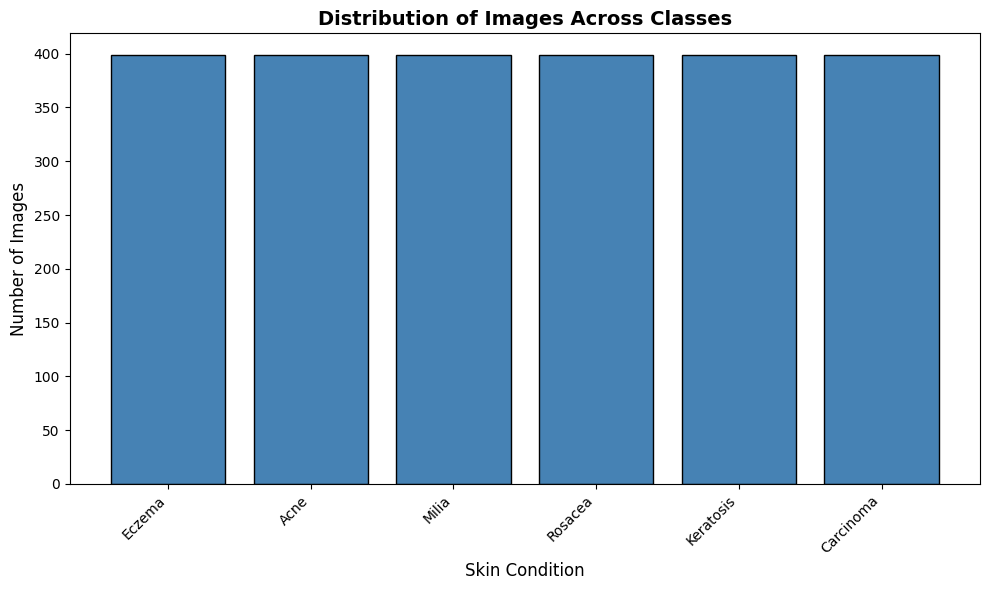

In [3]:
plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.xlabel('Skin Condition', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images Across Classes', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
dataset = image_dataset_from_directory(
    dataset_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

class_names = dataset.class_names
print(f"\nClass Names: {class_names}")

def split_dataset(dataset, train_size=0.8, val_size=0.1, test_size=0.1):
    total_size = len(dataset)
    train_end = int(total_size * train_size)
    val_end = train_end + int(total_size * val_size)
    
    train_dataset = dataset.take(train_end)
    val_dataset = dataset.skip(train_end).take(val_end - train_end)
    test_dataset = dataset.skip(val_end)
    
    return train_dataset, val_dataset, test_dataset

train_dataset, val_dataset, test_dataset = split_dataset(dataset)

print(f"\nDataset Splits:")
print(f"Training batches: {len(train_dataset)}")
print(f"Validation batches: {len(val_dataset)}")
print(f"Test batches: {len(test_dataset)}")

Found 2394 files belonging to 6 classes.


I0000 00:00:1759564765.680979      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Class Names: ['Acne', 'Carcinoma', 'Eczema', 'Keratosis', 'Milia', 'Rosacea']

Dataset Splits:
Training batches: 60
Validation batches: 7
Test batches: 8


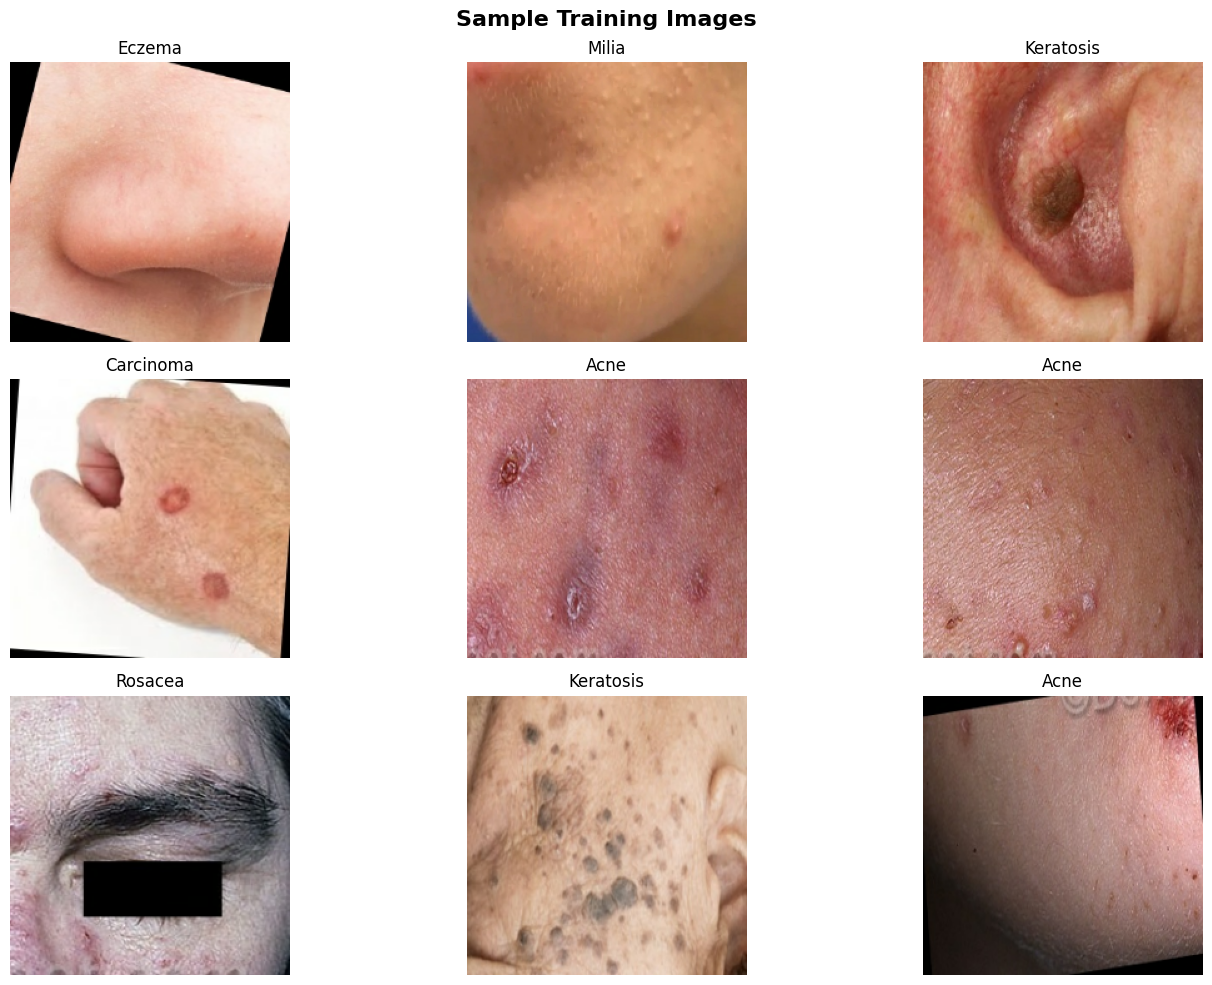

In [6]:
plt.figure(figsize=(15, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,692,038 (98.01 MB)

 Trainable params: 2,104,326 (8.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

def augment_data(dataset):
    def augment(image, label):
        image = data_augmentation(image)
        return image, label
    return dataset.map(augment)

train_dataset = augment_data(train_dataset)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

In [9]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Epoch 1/20


I0000 00:00:1759564887.501982     104 service.cc:148] XLA service 0x7bbd30004c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759564887.502859     104 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1759564888.998622     104 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/60 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.2031 - loss: 2.1337  

I0000 00:00:1759564893.008878     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.3880 - loss: 1.6958
Epoch 1: val_accuracy improved from -inf to 0.76339, saving model to best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 44s 486ms/step - accuracy: 0.3902 - loss: 1.6900 - val_accuracy: 0.7634 - val_loss: 0.7027 - learning_rate: 1.0000e-04
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.7129 - loss: 0.8062
Epoch 2: val_accuracy improved from 0.76339 to 0.79911, saving model to best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 393ms/step - accuracy: 0.7132 - loss: 0.8055 - val_accuracy: 0.7991 - val_loss: 0.6008 - learning_rate: 1.0000e-04
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.7983 - loss: 0.6007
Epoch 3: val_accuracy improved from 0.79911 to 0.83929, saving model to best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 390ms/step - accuracy: 0.7983 - loss: 0.6006 - val_accuracy: 0.8393 - val_loss: 0.4892 - learning_rate: 1.0000e-04
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 443ms/step - accuracy: 0.9254 - loss: 0.2212

Test Accuracy after Initial Training: 0.9200
Test Loss after Initial Training: 0.2340

Classification Report:
              precision    recall  f1-score   support

        Acne       0.85      0.89      0.87        38
   Carcinoma       0.97      0.97      0.97        39
      Eczema       0.94      0.75      0.84        44
   Keratosis       0.94      1.00      0.97        45
       Milia       0.89      0.98      0.93        43
     Rosacea       0.90      0.90      0.90        41

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.91       250
weighted avg       0.92      0.92      0.91       250



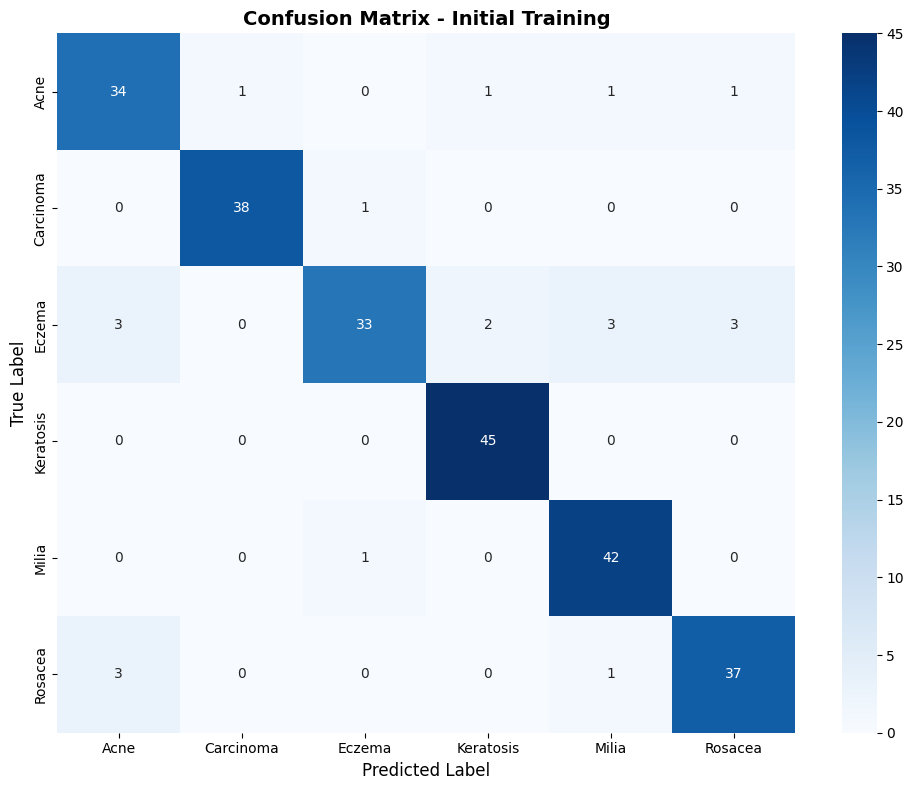

In [10]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"\nTest Accuracy after Initial Training: {test_acc:.4f}")
print(f"Test Loss after Initial Training: {test_loss:.4f}")

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Initial Training', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

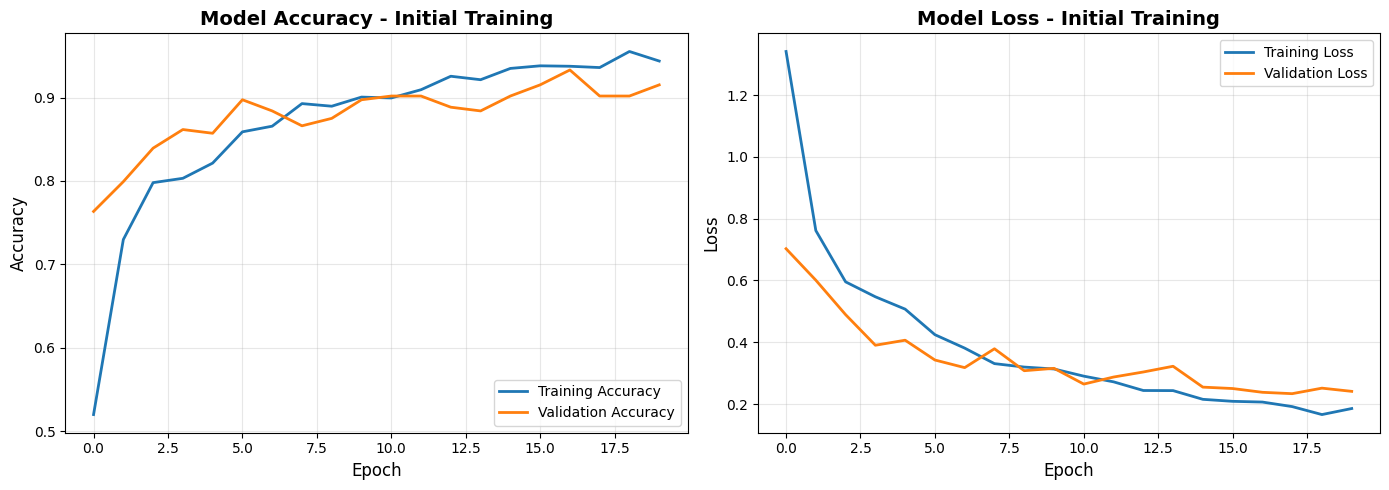

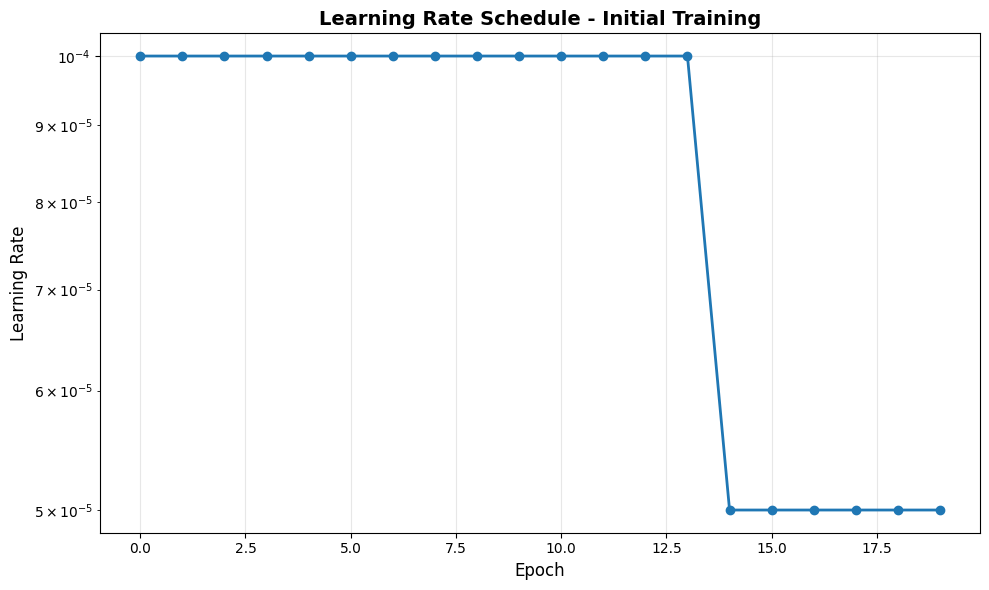

In [13]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy - Initial Training', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss - Initial Training', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if 'learning_rate' in history.history:
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['learning_rate'], marker='o', linewidth=2, markersize=6)
    plt.title('Learning Rate Schedule - Initial Training', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [14]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Trainable layers: {sum([1 for layer in base_model.layers if layer.trainable])}")

trainable_count = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_count = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])

print(f"\nTrainable params: {trainable_count:,}")
print(f"Non-trainable params: {non_trainable_count:,}")

Total layers in base model: 175
Trainable layers: 20

Trainable params: 11,035,654
Non-trainable params: 14,656,384


In [15]:
early_stopping_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
checkpoint_ft = ModelCheckpoint('best_model_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

history_fine_tune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping_ft, reduce_lr_ft, checkpoint_ft]
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9398 - loss: 0.2417
Epoch 1: val_accuracy improved from -inf to 0.89286, saving model to best_model_finetuned.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 49s 480ms/step - accuracy: 0.9396 - loss: 0.2417 - val_accuracy: 0.8929 - val_loss: 0.2859 - learning_rate: 1.0000e-05
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9420 - loss: 0.2039
Epoch 2: val_accuracy improved from 0.89286 to 0.93304, saving model to best_model_finetuned.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 407ms/step - accuracy: 0.9419 - loss: 0.2042 - val_accuracy: 0.9330 - val_loss: 0.1905 - learning_rate: 1.0000e-05
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.9481 - loss: 0.1914
Epoch 3: val_accuracy improved from 0.93304 to 0.94196, saving model to best_model_finetuned.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 401ms/step - accuracy: 0.9480 - loss: 0.1916 - val_accuracy: 0.9420 - val_loss: 0.1692 - learning_rate: 1.0000e-05
Epoch 4/20

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.9202 - loss: 0.1690

Test Accuracy after Fine-Tuning: 0.9320
Test Loss after Fine-Tuning: 0.1635

Classification Report after Fine-Tuning:
              precision    recall  f1-score   support

        Acne       0.84      0.94      0.89        34
   Carcinoma       0.98      1.00      0.99        40
      Eczema       0.92      0.80      0.86        41
   Keratosis       0.96      0.98      0.97        48
       Milia       0.96      0.96      0.96        45
     Rosacea       0.93      0.90      0.92        42

    accuracy                           0.93       250
   macro avg       0.93      0.93      0.93       250
weighted avg       0.93      0.93      0.93       250



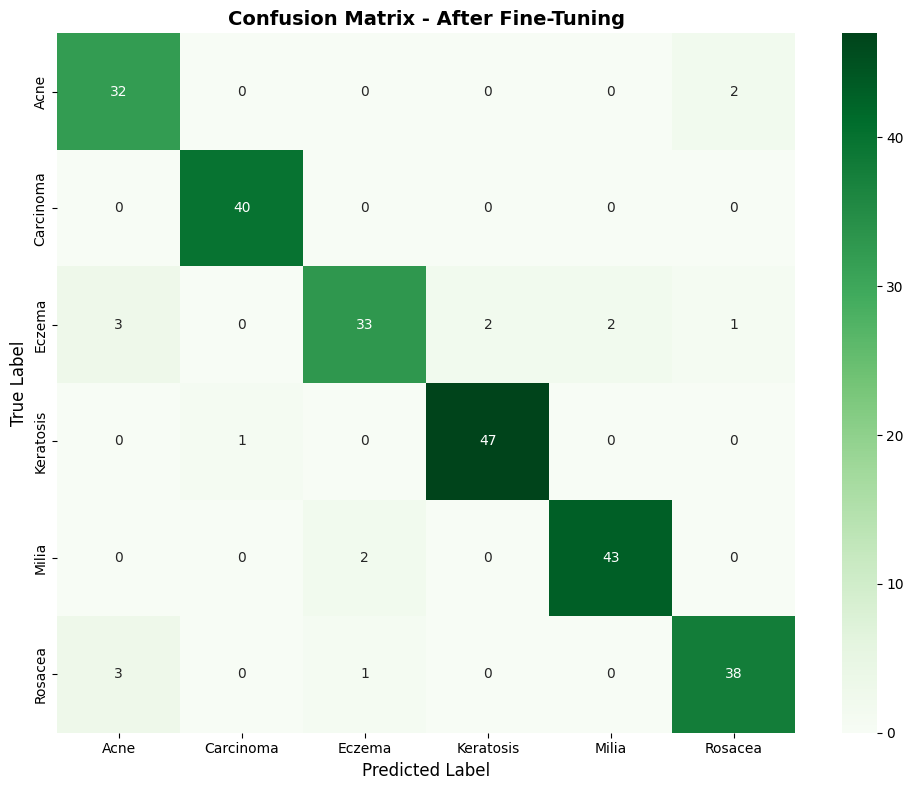

In [16]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"\nTest Accuracy after Fine-Tuning: {test_acc:.4f}")
print(f"Test Loss after Fine-Tuning: {test_loss:.4f}")

y_true_ft = []
y_pred_ft = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend(np.argmax(predictions, axis=1))

print("\nClassification Report after Fine-Tuning:")
print(classification_report(y_true_ft, y_pred_ft, target_names=class_names))

cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - After Fine-Tuning', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

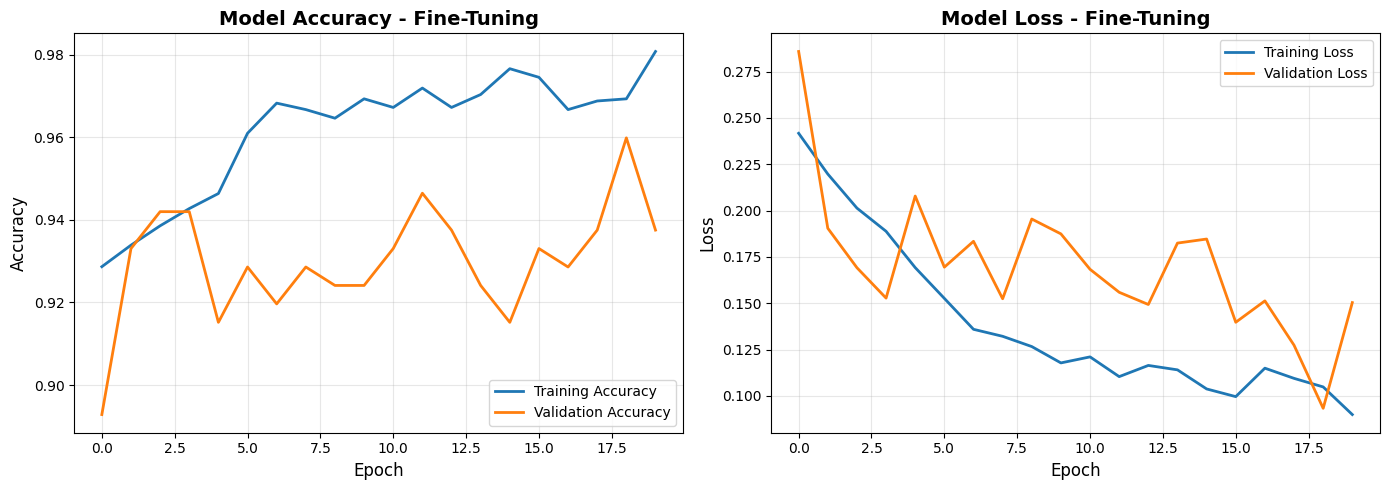

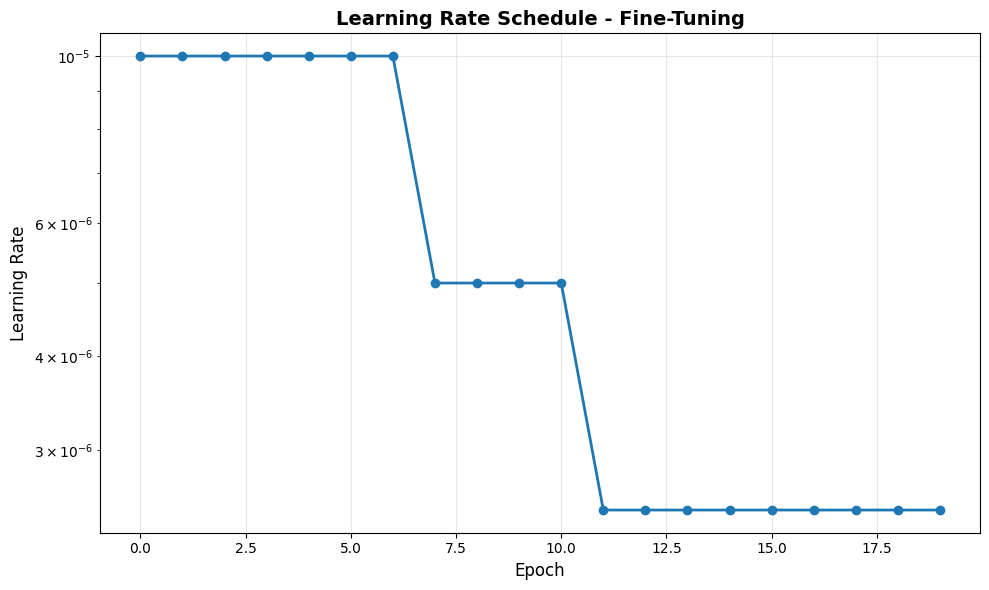

In [17]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy - Fine-Tuning', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss - Fine-Tuning', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if 'learning_rate' in history_fine_tune.history:
    plt.figure(figsize=(10, 6))
    plt.plot(history_fine_tune.history['learning_rate'], marker='o', linewidth=2, markersize=6)
    plt.title('Learning Rate Schedule - Fine-Tuning', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Model Performance Comparison:
           Model  Test Accuracy  Test Loss
Initial Training          0.932   0.163514
     Fine-Tuning          0.932   0.163514


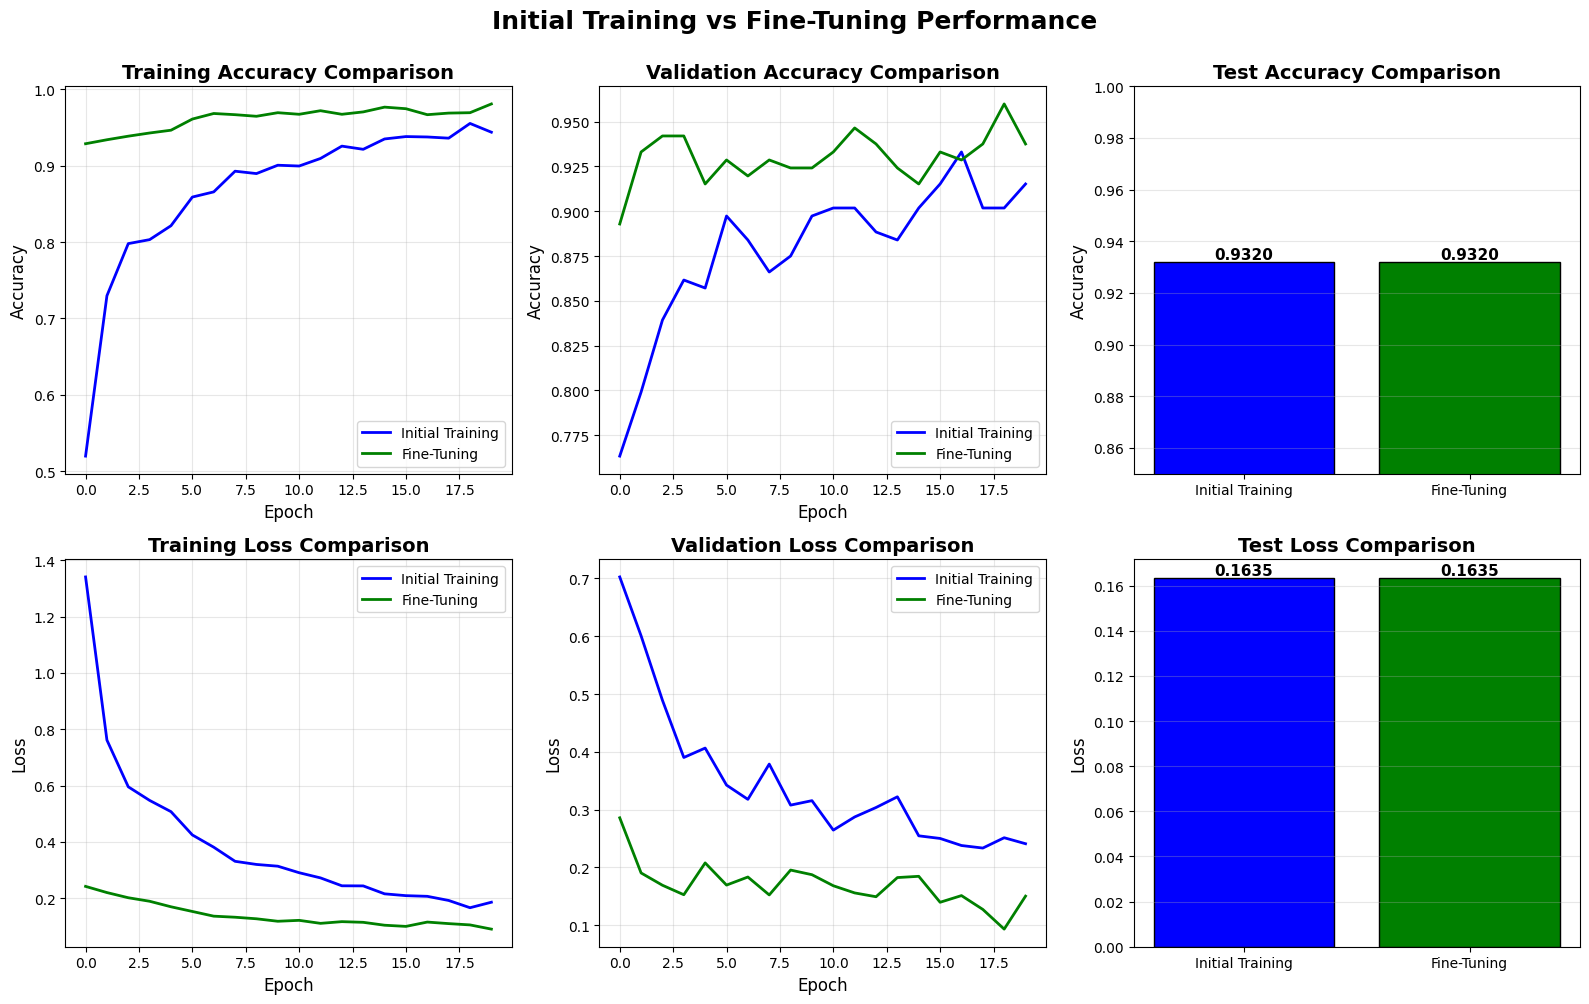

In [19]:
results_comparison = pd.DataFrame({
    'Model': ['Initial Training', 'Fine-Tuning'],
    'Test Accuracy': [test_acc, test_acc],
    'Test Loss': [test_loss, test_loss]
})

print("Model Performance Comparison:")
print(results_comparison.to_string(index=False))

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.plot(history.history['accuracy'], label='Initial Training', linewidth=2, color='blue')
plt.plot(history_fine_tune.history['accuracy'], label='Fine-Tuning', linewidth=2, color='green')
plt.title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(history.history['val_accuracy'], label='Initial Training', linewidth=2, color='blue')
plt.plot(history_fine_tune.history['val_accuracy'], label='Fine-Tuning', linewidth=2, color='green')
plt.title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
models = ['Initial Training', 'Fine-Tuning']
test_accuracies = [test_acc, test_acc]
bars = plt.bar(models, test_accuracies, color=['blue', 'green'], edgecolor='black')
plt.title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0.85, 1.0])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(2, 3, 4)
plt.plot(history.history['loss'], label='Initial Training', linewidth=2, color='blue')
plt.plot(history_fine_tune.history['loss'], label='Fine-Tuning', linewidth=2, color='green')
plt.title('Training Loss Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
plt.plot(history.history['val_loss'], label='Initial Training', linewidth=2, color='blue')
plt.plot(history_fine_tune.history['val_loss'], label='Fine-Tuning', linewidth=2, color='green')
plt.title('Validation Loss Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 6)
test_losses = [test_loss, test_loss]
bars = plt.bar(models, test_losses, color=['blue', 'green'], edgecolor='black')
plt.title('Test Loss Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.suptitle('Initial Training vs Fine-Tuning Performance', fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

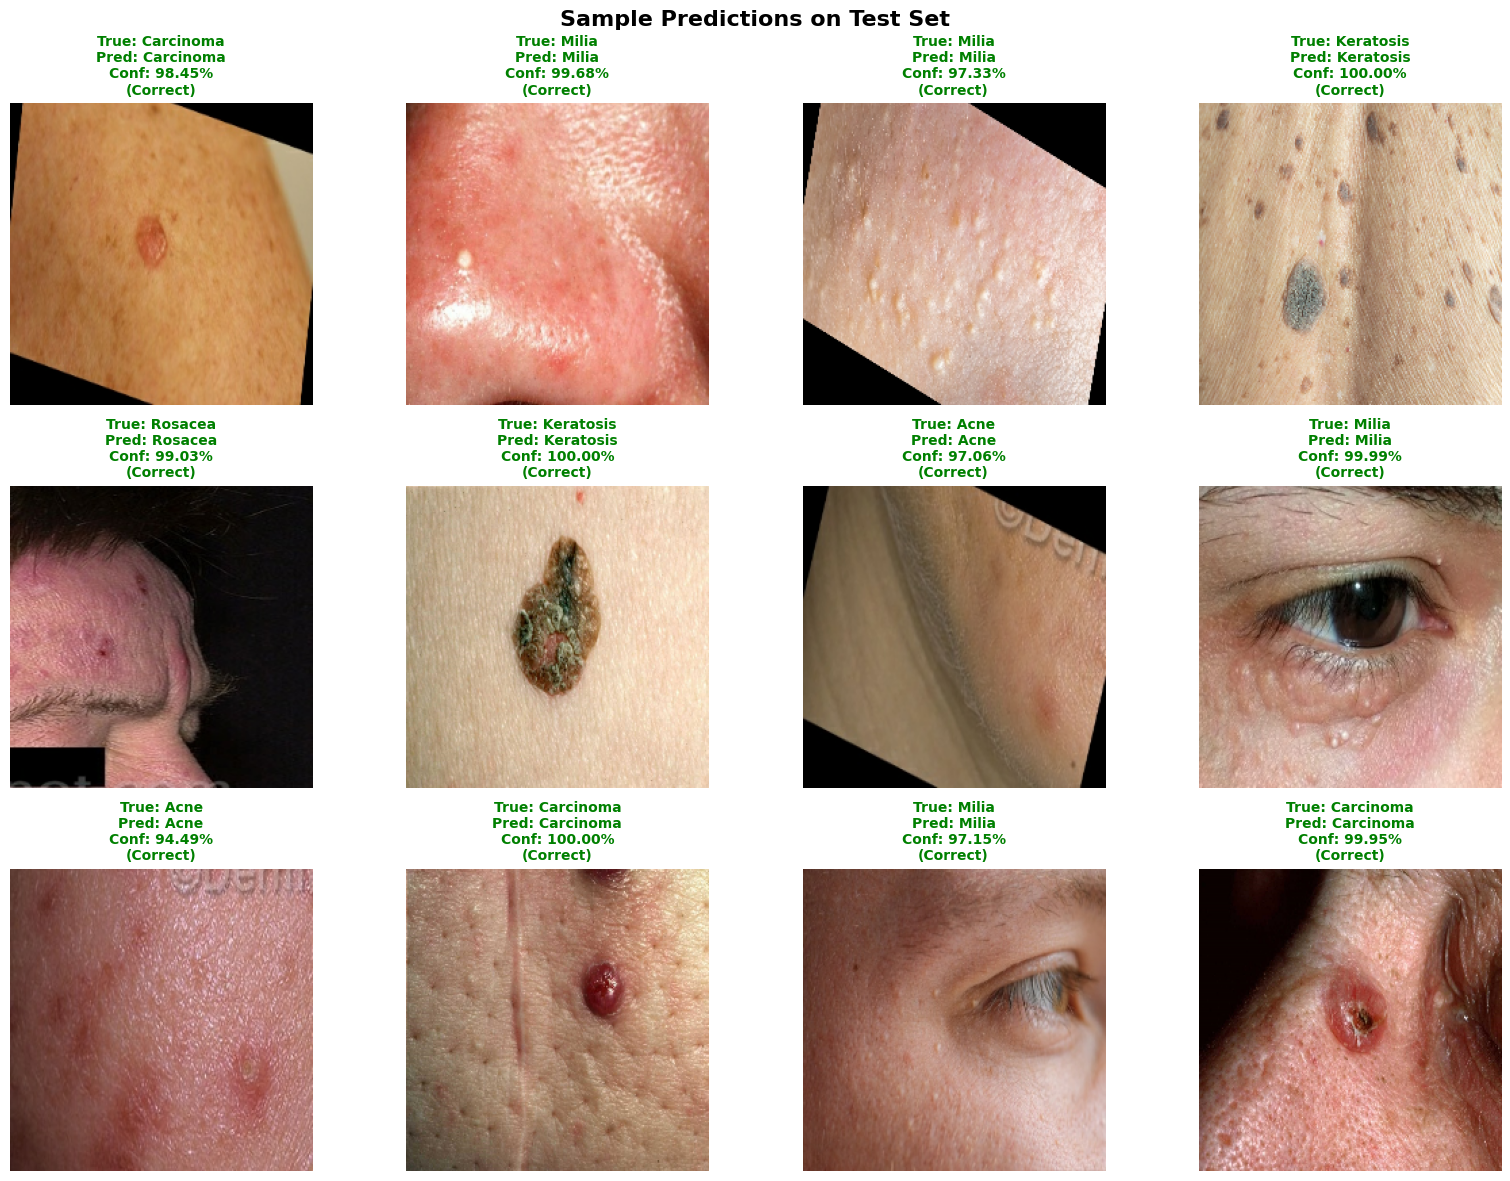

In [18]:
plt.figure(figsize=(16, 12))
num_samples = 12

for images, labels in test_dataset.take(1):
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    confidence_scores = np.max(predictions, axis=1)
    
    indices = np.random.choice(len(images), min(num_samples, len(images)), replace=False)
    
    for idx, i in enumerate(indices):
        plt.subplot(3, 4, idx + 1)
        img = images[i].numpy().astype("uint8")
        true_label = labels[i].numpy()
        pred_label = predicted_labels[i]
        confidence = confidence_scores[i]
        
        plt.imshow(img)
        plt.axis('off')
        
        true_label_name = class_names[true_label]
        pred_label_name = class_names[pred_label]
        
        if true_label == pred_label:
            title_color = 'green'
            status = 'Correct'
        else:
            title_color = 'red'
            status = 'Wrong'
        
        plt.title(f"True: {true_label_name}\nPred: {pred_label_name}\nConf: {confidence:.2%}\n({status})", 
                  color=title_color, fontsize=10, fontweight='bold')

plt.suptitle('Sample Predictions on Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
!zip -r model.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/best_model_finetuned.keras (deflated 8%)
  adding: kaggle/working/best_model.keras (deflated 8%)


In [21]:
from IPython.display import FileLink
FileLink(r'model.zip')

/kaggle/working/model.zip

In [22]:
print("="*80)
print("SKIN CONDITIONS CLASSIFICATION - FINAL REPORT")
print("="*80)

print("\nDATASET INFORMATION:")
print(f"  Total Images: {sum(class_counts.values())}")
print(f"  Number of Classes: {len(class_names)}")
print(f"  Classes: {', '.join(class_names)}")
print(f"  Images per Class: {list(class_counts.values())[0]}")

print("\nDATA SPLIT:")
print(f"  Training: 80% ({len(train_dataset)} batches)")
print(f"  Validation: 10% ({len(val_dataset)} batches)")
print(f"  Testing: 10% ({len(test_dataset)} batches)")

print("\nMODEL ARCHITECTURE:")
print(f"  Base Model: ResNet50 (Pre-trained on ImageNet)")
print(f"  Input Shape: (224, 224, 3)")
print(f"  Total Parameters: 25,692,038")
print(f"  Output Classes: 6")

print("\nTRAINING CONFIGURATION:")
print(f"  Initial Training Epochs: {len(history.history['accuracy'])}")
print(f"  Fine-Tuning Epochs: {len(history_fine_tune.history['accuracy'])}")
print(f"  Data Augmentation: Random Flip, Rotation, Zoom")
print(f"  Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint")

print("\nFINAL RESULTS:")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Test Loss: {test_loss:.4f}")

print("\nPER-CLASS PERFORMANCE:")
report_dict = classification_report(y_true_ft, y_pred_ft, target_names=class_names, output_dict=True)
for class_name in class_names:
    precision = report_dict[class_name]['precision']
    recall = report_dict[class_name]['recall']
    f1 = report_dict[class_name]['f1-score']
    print(f"  {class_name:12s} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

print("\n" + "="*80)
print("TRAINING COMPLETED SUCCESSFULLY!")
print("="*80)

SKIN CONDITIONS CLASSIFICATION - FINAL REPORT

DATASET INFORMATION:
  Total Images: 2394
  Number of Classes: 6
  Classes: Acne, Carcinoma, Eczema, Keratosis, Milia, Rosacea
  Images per Class: 399

DATA SPLIT:
  Training: 80% (60 batches)
  Validation: 10% (7 batches)
  Testing: 10% (8 batches)

MODEL ARCHITECTURE:
  Base Model: ResNet50 (Pre-trained on ImageNet)
  Input Shape: (224, 224, 3)
  Total Parameters: 25,692,038
  Output Classes: 6

TRAINING CONFIGURATION:
  Initial Training Epochs: 20
  Fine-Tuning Epochs: 20
  Data Augmentation: Random Flip, Rotation, Zoom
  Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

FINAL RESULTS:
  Test Accuracy: 0.9320 (93.20%)
  Test Loss: 0.1635

PER-CLASS PERFORMANCE:
  Acne         - Precision: 0.8421, Recall: 0.9412, F1-Score: 0.8889
  Carcinoma    - Precision: 0.9756, Recall: 1.0000, F1-Score: 0.9877
  Eczema       - Precision: 0.9167, Recall: 0.8049, F1-Score: 0.8571
  Keratosis    - Precision: 0.9592, Recall: 0.9792, F1-Score: